# Understanding the Data Structure
## A. Metadata (Before [Curve Data])
##### This section provides session details:
###### Threshold: 0.80
###### Breath Hold Duration: 20 seconds
###### Trigger on Inhale: True
###### Patient Info: Name (BENNY MARTIS), ID (5482024), Date (07-11-2024), Time (08:17:39).
## B. Key Definitions
The Balloon Valve Status column has 5 possible states:

### Status	Meaning
### 1	Deflated
### 2	Ready to inflate at inhale threshold
### 3	Ready to inflate at exhale threshold
### 4	Inflated
### 5	Fault
The Patient Switch column has 2 states:

## Status	Meaning
## 0	Disabled
## 1	Enabled

# 1. Loading the .dat File

In [1]:
import pandas as pd

# Define the file path
file_path = "BENNY MARTIS_ct.dat"

# Read the file and extract the relevant data (after "HeaderEnd")
with open(file_path, "r") as file:
    lines = file.readlines()

# Find the index where data starts (after "HeaderEnd")
start_index = lines.index("HeaderEnd\n") + 1

# Read data into a Pandas DataFrame
data = [line.strip().split(";") for line in lines[start_index:]]

# Define column names
columns = [
    "Session Time", "Volume (liters)", "Balloon Valve Status",
    "Patient Switch", "Gating Mode", "Gating Status", "Relay State"
]

# Convert to DataFrame
df = pd.DataFrame(data, columns=columns)

# Convert numeric columns to proper data types
df["Session Time"] = df["Session Time"].astype(float)
df["Volume (liters)"] = df["Volume (liters)"].astype(float)
df["Balloon Valve Status"] = df["Balloon Valve Status"].astype(int)
df["Patient Switch"] = df["Patient Switch"].astype(int)

# Display first few rows
print(df.head())


   Session Time  Volume (liters)  Balloon Valve Status  Patient Switch  \
0          4.88            0.312                     1               0   
1          4.90            0.320                     1               0   
2          4.92            0.328                     1               0   
3          4.94            0.336                     1               0   
4          4.96            0.344                     1               0   

      Gating Mode Gating Status Relay State  
0  Manual Overide                            
1              -             -            -  
2              -             -            -  
3              -             -            -  
4              -             -            -  


In [5]:
print(df["Balloon Valve Status"].value_counts())


Balloon Valve Status
1    37992
4     4245
2     1577
Name: count, dtype: int64


# Analyzing Breathing Patterns

### A. Estimating Breathing Rate

In [6]:
# Detecting transitions from 1 -> 2 -> 4 or direct 1 -> 4
breaths = ((df["Balloon Valve Status"].shift(1) == 1) & (df["Balloon Valve Status"].isin([2, 4]))).sum()

# Calculate session duration
session_duration = df["Session Time"].max() - df["Session Time"].min()

# Compute breathing rate per minute
breathing_rate = breaths / (session_duration / 60)

print(f"Estimated Breathing Rate: {breathing_rate:.2f} breaths per minute")


Estimated Breathing Rate: 0.55 breaths per minute


In [7]:
print(df[df["Balloon Valve Status"] == 4].head(10))  # Show first few occurrences of 4


      Session Time  Volume (liters)  Balloon Valve Status  Patient Switch  \
4397         92.82            0.804                     4               1   
4398         92.84            0.812                     4               1   
4399         92.86            0.820                     4               1   
4400         92.88            0.828                     4               1   
4401         92.90            0.836                     4               1   
4402         92.92            0.844                     4               1   
4403         92.94            0.852                     4               1   
4404         92.96            0.860                     4               1   
4405         92.98            0.868                     4               1   
4406         93.00            0.876                     4               1   

     Gating Mode Gating Status Relay State  
4397          -             -            -  
4398          -             -            -  
4399          -  

In [15]:
# Consider only active patient participation
active_df = df[df["Patient Switch"] == 1]

# Detecting valid breath events during active periods
breaths = ((active_df["Balloon Valve Status"].shift(1) == 1) & (active_df["Balloon Valve Status"].isin([2, 4]))).sum()

# Calculate duration of active participation
active_duration = active_df["Session Time"].max() - active_df["Session Time"].min()

# Compute breathing rate per minute (only during active participation)
breathing_rate = breaths / (active_duration / 60)

print(f"Estimated Breathing Rate (Active Time): {breathing_rate:.2f} breaths per minute")


Estimated Breathing Rate (Active Time): 0.79 breaths per minute


### B. Detecting Breath Hold Duration

In [3]:
breath_hold_duration = df[df["Balloon Valve Status"] == 4]["Session Time"].max() - df[df["Balloon Valve Status"] == 4]["Session Time"].min()
print(f"Detected Breath Hold Duration: {breath_hold_duration:.2f} seconds")


Detected Breath Hold Duration: 522.54 seconds


### C. Visualizing the Breathing Pattern

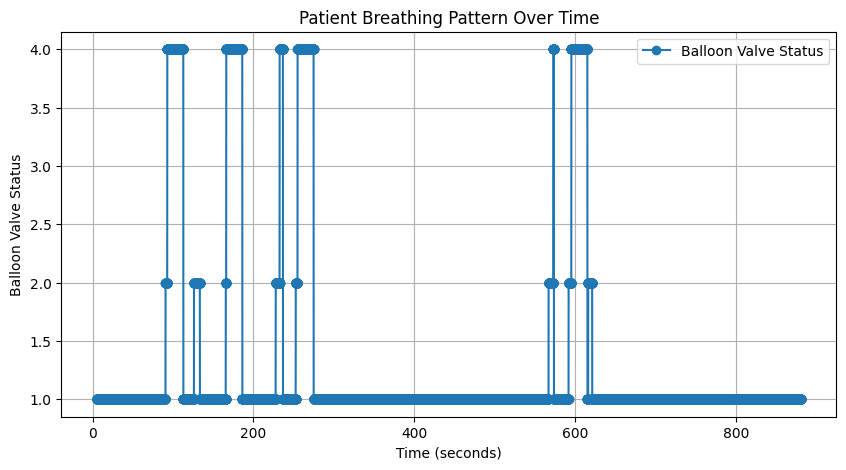

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["Session Time"], df["Balloon Valve Status"], marker="o", linestyle="-", label="Balloon Valve Status")
plt.xlabel("Time (seconds)")
plt.ylabel("Balloon Valve Status")
plt.title("Patient Breathing Pattern Over Time")
plt.legend()
plt.grid()
plt.show()
